In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
sns.set_theme(style='whitegrid')

In [3]:
df = pd.read_csv('spf.csv')

In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [89]:
##Exercise 1
mean = df['Hours_Studied'].mean()
median = df['Hours_Studied'].median()
mode = df['Hours_Studied'].mode()
std = df['Hours_Studied'].std()
q_1 = df['Hours_Studied'].quantile(0.25)
q_3 = df['Hours_Studied'].quantile(0.75)
IQR = q_3 - q_1 




print(f'Mean: {mean: .2f}')
print(f'Median: {median: .2f}')
print(f'Mode: {mode}')
print(f'Stand_dev: {std: .2f}')
print(f'IQR: {IQR: .2f}')

Mean:  19.98
Median:  20.00
Mode: 0    20
Name: Hours_Studied, dtype: int64
Stand_dev:  5.99
IQR:  8.00


In [90]:
df['Hours_Studied'].describe()
#Exercise 2

count    6607.000000
mean       19.975329
std         5.990594
min         1.000000
25%        16.000000
50%        20.000000
75%        24.000000
max        44.000000
Name: Hours_Studied, dtype: float64

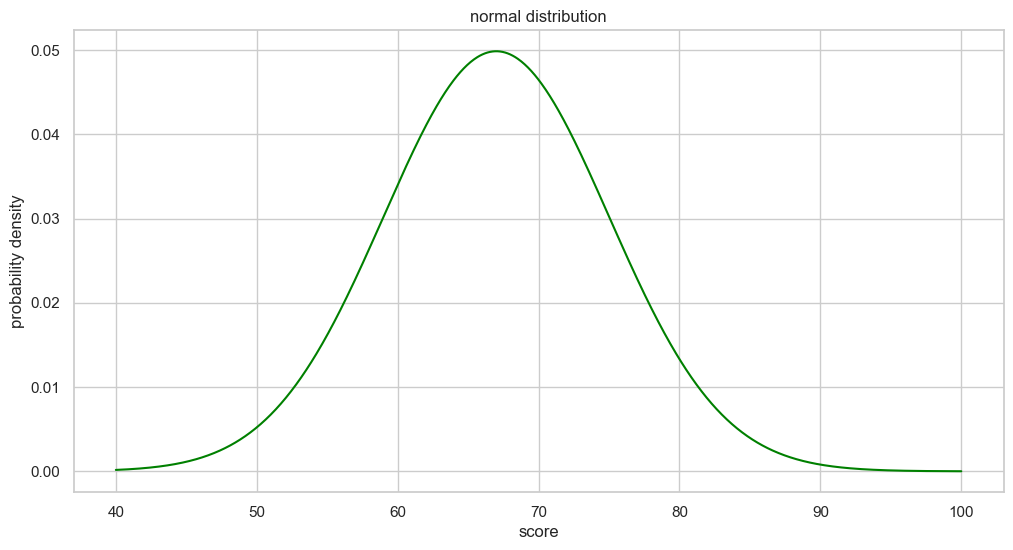

In [91]:
## Exercise 3

from scipy.stats import norm 


mean = 67
std = 8
x = np.linspace(40, 100, 1000)
y = norm.pdf(x, mean, std)


#plot it!
plt.figure(figsize=(12,6))
plt.plot(x, y, color='green', linewidth=1.5)
plt.title('normal distribution')
plt.xlabel('score')
plt.ylabel('probability density')
plt.show()

In [26]:
#Exercise 5
prob = norm.cdf(75, 67.235659, 3.890456)
print(f'P(Exam score<= 75) = {prob: .3f}')

P(Exam score<= 75) =  0.977


In [92]:
#Exercise 6
score_95 = norm.ppf(0.95, 67.235659,  3.890456)

print(f'95th percentile score = {score_95: .2f}')


95th percentile score =  73.63


In [40]:
# EXamples
from scipy.stats import binom

n = 10 
p = 0.7
prob_7 = binom.pmf(7, n, p)
print(f'P(exactly 7 pass) = {prob_7: .4f}')

P(exactly 7 pass) =  0.2668


In [39]:
# EXamples
n = 10
p = 0.7
prob_at_most_7 = binom.cdf(7, n, p)
print(f'P(at most 7 pass) = {prob_at_most_7: .4f}')

P(at most 7 pass) =  0.6172


In [38]:
# EXamples
x = np.arange(0, 11)
y = binom.pmf(x, n, p)

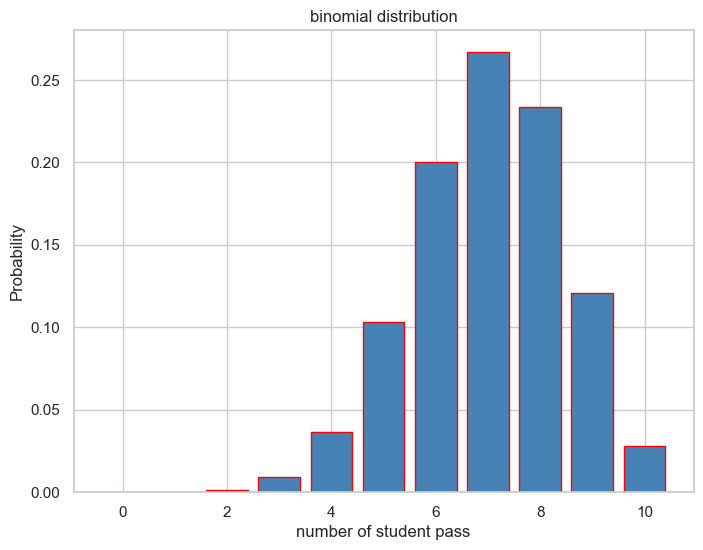

In [47]:
# EXamples
plt.figure(figsize=(8,6))
plt.bar(x, y, color='steelblue', edgecolor='red')
plt.title('binomial distribution')
plt.xlabel('number of student pass')
plt.ylabel('Probability')
plt.show()

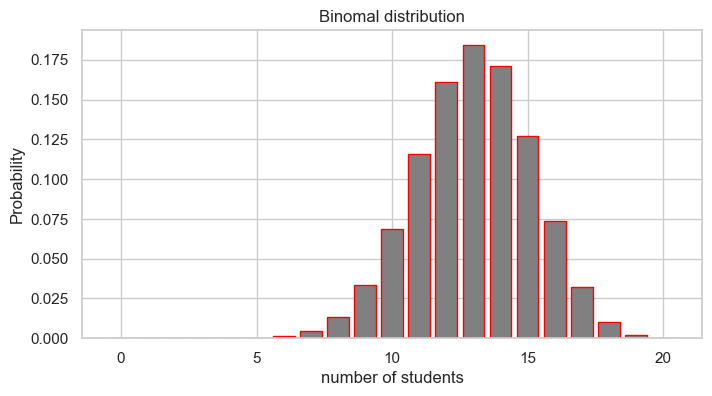

In [46]:
# Exercise 4 
ns = 20
ps = 0.65

xs = np.arange(0, 21)
ys = binom.pmf(xs, ns, ps)

plt.figure(figsize=(8,4))
plt.bar(xs, ys, color='gray', edgecolor='red')
plt.title('Binomal distribution')
plt.xlabel('number of students')
plt.ylabel('Probability')
plt.show()

In [49]:
## Examples
from scipy.stats import poisson

am = 3
prob_5 = poisson.pmf(5, am)
print(f'P(exactly 5) = {prob_5: .4f}')

P(exactly 5) =  0.1008


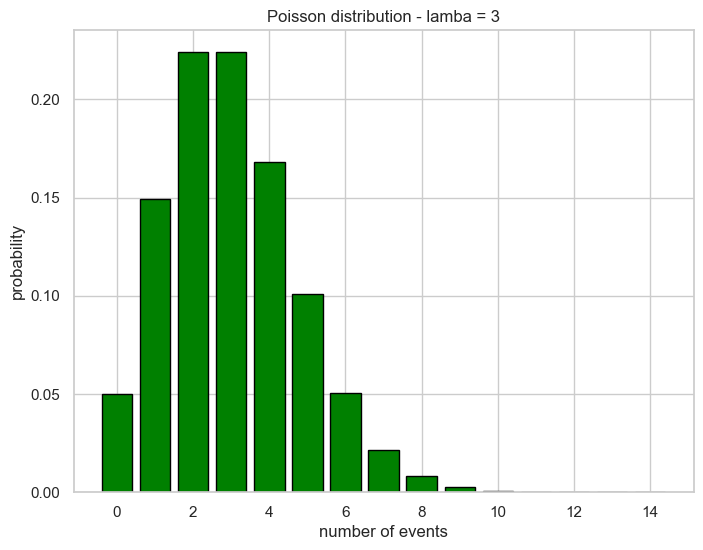

In [85]:
# Example: plot it
x = np.arange(0, 15)
y = poisson.pmf(x, am)

plt.figure(figsize=(8,6))
plt.bar(x, y, color='green', edgecolor='black')
plt.title(f'Poisson distribution - lamba = {am}')
plt.xlabel('number of events')
plt.ylabel('probability')
plt.show()

### Chi-Square test and TTest

In [69]:
from scipy.stats import ttest_1samp
from scipy.stats import chi2_contingency

In [86]:
#examples
t_stat , p_value = ttest_1samp(df['Exam_Score'], 70)
print(f'T-statistic: {t_stat: .4f}')
print(f'P-value: {p_value: .4f}')

if p_value < 0.05:
    print('Reject H_null, mean is significant different from 70')
else:
    print('Failed to reject H_null, no significant difference from 70')


T-statistic: -57.7555
P-value:  0.0000
Reject H_null, mean is significant different from 70


In [87]:
#Examples
contingency_table = pd.crosstab(df['School_Type'], df['Parental_Involvement'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Chi2: {chi2:.4f}')
print(f'P-value: {p_value: .4f}')

Chi2: 3.1244
P-value:  0.2097


In [88]:
#Examples
if p_value < 0.05:
    print('significant relationship exists')
else:
    print('no significant relationship')

no significant relationship


In [70]:
#Exercise 7 
t_stat , p_value = ttest_1samp(df['Exam_Score'], 65)
print(f'T-statistic: {t_stat: .4f}')
print(f'P-value: {p_value: .4f}')

if p_value < 0.05:
    print('Reject H_null, mean is significant different from 65')
else:
    print('Failed to reject H_null, no significant difference from 65')


T-statistic:  46.7097
P-value:  0.0000
Reject H_null, mean is significant different from 65


In [72]:
#Exercise 10 
cont_table = pd.crosstab(df['School_Type'], df['Internet_Access'])
chi2, p_value, dof, expected = chi2_contingency(cont_table)
print(f'Chi2: {chi2:.4f}')
print(f'P-value: {p_value: .4f}')
if p_value < 0.05:
    print('significant relationship exists')
else:
    print('no significant relationship')

Chi2: 0.9775
P-value:  0.3228
no significant relationship


## correlation in python

In [73]:
from scipy.stats import pearsonr, spearmanr

In [82]:
r, p_value = pearsonr(df['Hours_Studied'], df['Exam_Score'])
print(f'Pearson r: {r:.4f}, P-value: {p_value: .4f}')

print(f'r is {r:.4f}, meaning there is a moderate retionship')

Pearson r: 0.4455, P-value:  0.0000
r is 0.4455, meaning there is a moderate retionship


In [84]:
rho, p_value = spearmanr(df['Attendance'], df['Exam_Score'])
print(f'Spearman rank Rho: {rho:.4f}, P-value: {p_value: .4f}')
print(f'spearman rank rho is {rho: .4f}, meaning there is a strong reletionship')

Spearman rank Rho: 0.6724, P-value:  0.0000
spearman rank rho is  0.6724, meaning there is a strong reletionship
